# SECTION 1 — Environment Setup

# Abalone Regression Experiment

This notebook evaluates the performance of:

- Single regression
- MixCobra and GradientCobra aggregation

on the Abalone dataset.

Metrics:
- MAE
- MSE
- RMSE
- R2

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)


# SECTION 2 — Dataset Loading

In [2]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

path = dataset_download("rodolfomendes/abalone-dataset")
os.listdir(path)


['abalone.csv']

In [3]:
df = pd.read_csv(os.path.join(path, "abalone.csv"))
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


# SECTION 3 — Exploratory Data Analysis

In [4]:
print(df.shape)
df.info()

(4177, 9)
<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


In [5]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

# SECTION 4 — Data Preprocessing

In [6]:
target = "Rings"

X = df.drop(columns=[target])
y = df[target]

In [7]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [9]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# SECTION 5 — Train Models

In [10]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

models = {
    "ridge": Ridge(alpha=1.0),
    "random_forest_regressor" : RandomForestRegressor(n_estimators=300, random_state=42),
    "svr": SVR(),
    "gradient_boosting_regressor" : GradientBoostingRegressor(),
    "k_neighbors_regressor": KNeighborsRegressor()
}

def evaluate_regression(y_true, y_pred):
    metrics = {
        "MAE" : mean_absolute_error(y_true, y_pred),
        "MSE" : mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2"  : r2_score(y_true, y_pred)
    }
    return metrics

In [11]:
results = {}
for name, model in models.items():
    clf = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    metrics = evaluate_regression(y_test, y_pred)
    results[name] = metrics

In [12]:
from cobra.gradientcobra import GradientCOBRA

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

gradientcobra = GradientCOBRA(
    estimators=models.keys(),
    random_state=42,
)
start_fit = time.perf_counter()
gradientcobra.fit(X_train_p, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred = gradientcobra.predict(X_test_p)
predict_time = time.perf_counter() - start_pred

metrics = evaluate_regression(y_test, y_pred)
results["gradientcobra"] = metrics
print(f"Results for gradientcobra: {metrics}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

search: 100%|██████████| 300/300 [00:03<00:00, 79.39it/s]


Results for gradientcobra: {'MAE': 1.5144057354337348, 'MSE': 4.672184299882183, 'RMSE': 2.16152360613577, 'R2': 0.5683978158188674}

Time computing : fit 6.821236332994886, predict 1.1939039579592645


In [13]:
gradientcobra.optimization_outputs_

{'method': 'grid',
 'optimizer': 'grid',
 'bandwidth': 6.020464882943144,
 'score': 4.612834649013999,
 'history':      iter      score       risk  bandwidth
 0       0  10.198071  10.198071   0.001000
 1       1  10.001293  10.001293   0.034441
 2       2   9.811680   9.811680   0.067883
 3       3   9.628933   9.628933   0.101324
 4       4   9.452768   9.452768   0.134766
 ..    ...        ...        ...        ...
 295   295   4.670529   4.670529   9.866234
 296   296   4.671360   4.671360   9.899676
 297   297   4.672196   4.672196   9.933117
 298   298   4.673035   4.673035   9.966559
 299   299   4.673879   4.673879  10.000000
 
 [300 rows x 4 columns],
 'evaluations': 300}

In [14]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="R2", ascending=False)

,MAE,MSE,RMSE,R2
gradientcobra,1.514406,4.672184,2.161524,0.568398
ridge,1.593908,4.891124,2.211589,0.548173
svr,1.513165,4.926428,2.219556,0.544912
random_forest_regressor,1.576085,5.001839,2.236479,0.537945
gradient_boosting_regressor,1.576581,5.056900,2.248755,0.532859
k_neighbors_regressor,1.607656,5.236364,2.288310,0.516281


<Axes: xlabel='bandwidth', ylabel='score'>

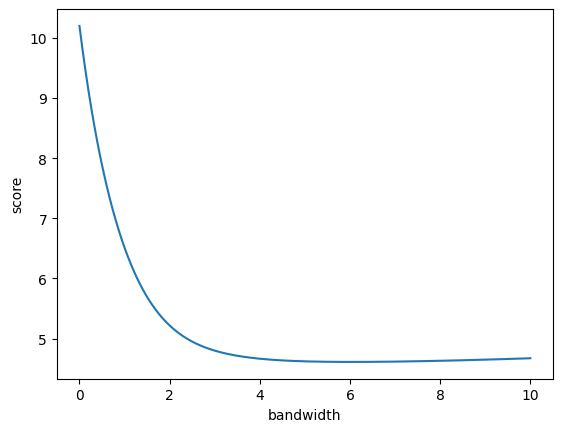

In [15]:
df_output = gradientcobra.optimization_outputs_['history']
sns.lineplot(df_output, x='bandwidth', y='score')

In [26]:
from cobra.mixcobra import MixCOBRARegressor

mixcobra = MixCOBRARegressor(
    opt_method="grad",
    optimizer="gd",
    random_state=42
)

start_fit = time.perf_counter()
mixcobra.fit(X_train_p, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred = mixcobra.predict(X_test_p)
predict_time = time.perf_counter() - start_pred

metrics = evaluate_regression(y_test, y_pred)
results["mixcobra"] = metrics
print(f"Results for mixcobra: {metrics}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

iter=300 | score=4.7569 | grad=[-0.00975597 -0.3141831 ] | lr=0.005371: 100%|██████████| 300/300 [00:20<00:00, 14.97it/s]

Results for mixcobra: {'MAE': 3.348181352496004, 'MSE': 13.791458351725277, 'RMSE': 3.71368527903554, 'R2': -0.2740130023975835}

Time computing : fit 20.5320335830329, predict 0.048963290988467634


In [17]:
mixcobra.optimization_outputs_

{'method': 'grid',
 'score': np.float64(4.577946610073681),
 'history':      iter      score       risk   alpha       beta
 0       0  10.193689  10.193689   0.001   0.001000
 1       1   6.788428   6.788428   0.001   0.527263
 2       2   5.415701   5.415701   0.001   1.053526
 3       3   4.896931   4.896931   0.001   1.579789
 4       4   4.707663   4.707663   0.001   2.106053
 ..    ...        ...        ...     ...        ...
 395   395   4.755158   4.755158  10.000   7.894947
 396   396   4.792065   4.792065  10.000   8.421211
 397   397   4.830974   4.830974  10.000   8.947474
 398   398   4.871541   4.871541  10.000   9.473737
 399   399   4.913461   4.913461  10.000  10.000000
 
 [400 rows x 5 columns],
 'evaluations': 400,
 'params': array([10.        ,  3.68484211])}

In [20]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="R2", ascending=False)

,MAE,MSE,RMSE,R2
gradientcobra,1.514406,4.672184,2.161524,0.568398
ridge,1.593908,4.891124,2.211589,0.548173
svr,1.513165,4.926428,2.219556,0.544912
random_forest_regressor,1.576085,5.001839,2.236479,0.537945
gradient_boosting_regressor,1.576581,5.056900,2.248755,0.532859
k_neighbors_regressor,1.607656,5.236364,2.288310,0.516281
mixcobra,4.232450,22.398214,4.732675,-1.069079


# SECTION 6 — External training

In [ ]:
X_base, X_agg, y_base, y_agg = train_test_split(
    X_train_p,
    y_train,
    test_size=0.5,
    random_state=42,
)

fit_models = {}
for name, model in models.items():
    model.fit(X_base, y_base)
    fit_models[name] = model

P_agg = np.column_stack([
    m.predict(X_agg)
    for m in fit_models.values()
])

P_test = np.column_stack([
    m.predict(X_test_p)
    for m in fit_models.values()
])

gradientcobra = GradientCOBRA(
    estimators=fit_models.keys(),
    random_state=42,
)

gradientcobra.fit(
    X=P_agg,
    y=y_agg,
    as_predictions=True
)

y_pred = gradientcobra.predict(
    X=P_test
)

metrics = evaluate_regression(y_test, y_pred)
metrics


search: 100%|██████████| 300/300 [00:03<00:00, 78.28it/s]


{'MAE': 1.5260630554396515,
 'MSE': 4.84869419747191,
 'RMSE': 2.2019750674046947,
 'R2': 0.552092367994124}